<a href="https://colab.research.google.com/github/talhanoor23/logistic_regression/blob/main/Creditcard_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import plotly.express as px
import os
%matplotlib inline

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
 89% 59.0M/66.0M [00:00<00:00, 153MB/s]
100% 66.0M/66.0M [00:00<00:00, 133MB/s]


In [ ]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [ ]:
df_credit = pd.read_csv('creditcard.csv')

In [ ]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df_credit.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df_credit.duplicated().sum()

1081

In [ ]:
df_credit = df_credit.drop_duplicates()

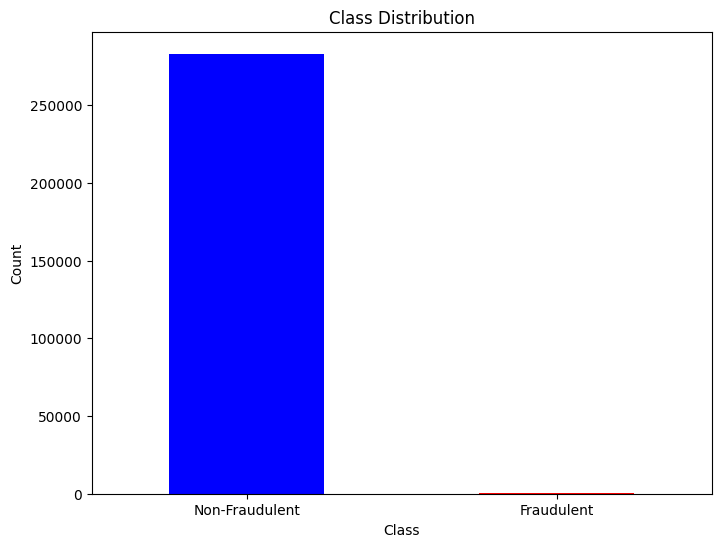

In [ ]:
class_count = df_credit['Class'].value_counts()
plt.figure(figsize=(8, 6))
class_count.plot(kind='bar',color = ['blue', 'red'])
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'], rotation = 0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

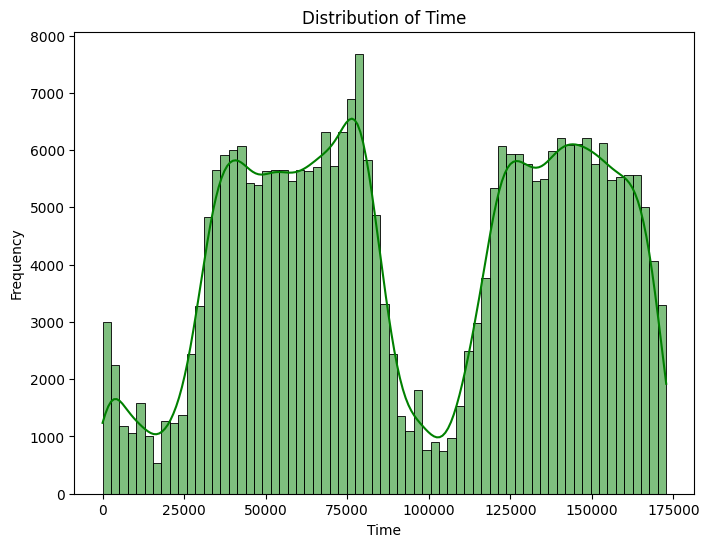

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df_credit['Time'], kde=True,color='g')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Distribution of Time')
plt.show()

In [ ]:
fraud = df_credit[df_credit['Class'] == 1]
non_fraud = df_credit[df_credit['Class'] == 0]

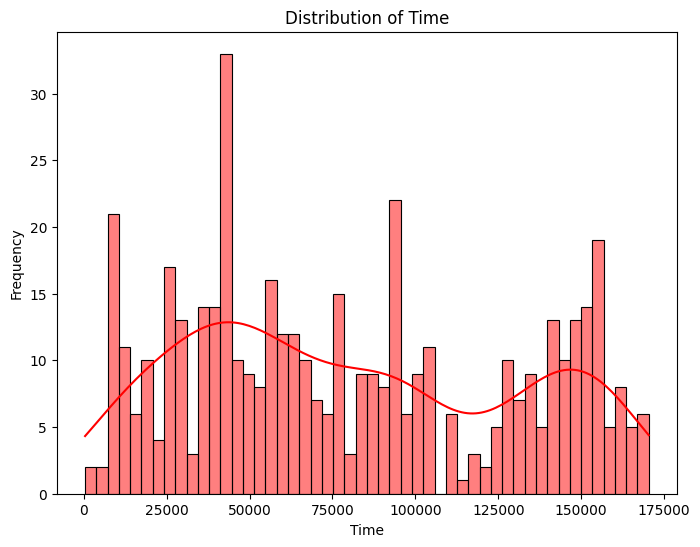

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(fraud['Time'], kde=True,color='r', bins =50)
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.title('Distribution of Time')
plt.show()

In [ ]:
X = df_credit.drop('Class', axis=1)
y = df_credit['Class']

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

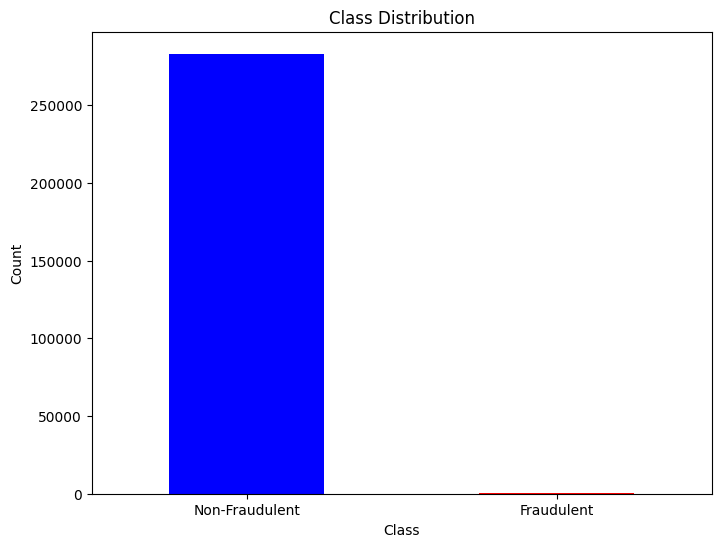

In [ ]:
class_count = y.value_counts()
plt.figure(figsize=(8, 6))
class_count.plot(kind='bar',color = ['blue', 'red'])
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'], rotation = 0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

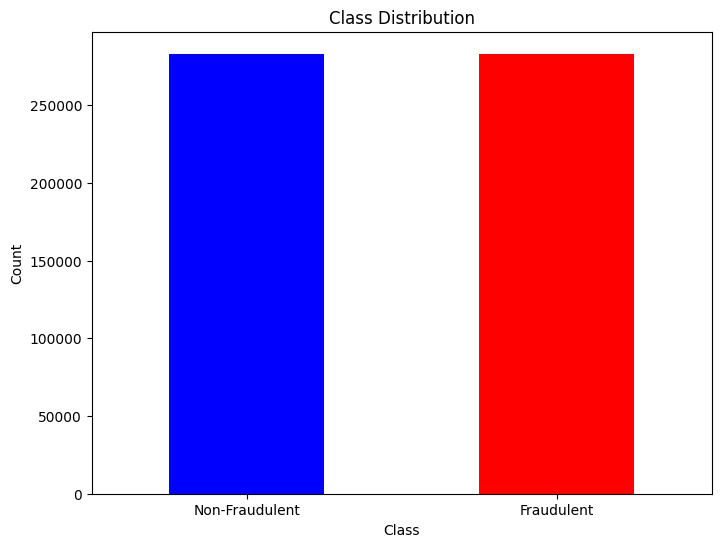

In [ ]:
class_count = y_resampled.value_counts()
plt.figure(figsize=(8, 6))
class_count.plot(kind='bar',color = ['blue', 'red'])
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'], rotation = 0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [ ]:
X.shape

(283726, 30)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [ ]:
%%time
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

CPU times: user 11 s, sys: 2.71 s, total: 13.7 s
Wall time: 7.92 s


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, recall_score, f1_score

In [ ]:
test_preds = model.predict(X_test)
train_preds = model.predict(X_train)

In [ ]:
test_pred_Df = pd.DataFrame({'Actual': y_test, 'Predicted': test_preds})
train_pred_df = pd.DataFrame({'Actual': y_train, 'Predicted': train_preds})

In [ ]:
test_pred_Df.head()

,Actual,Predicted
554816,1,1
19821,0,0
184234,0,0
503641,1,1
261118,0,0


In [ ]:
train_pred_df.head()

,Actual,Predicted
303464,1,1
1934,0,0
342085,1,1
224383,0,0
479262,1,1


In [ ]:
print(f"Train Accuracy: {accuracy_score(y_train, train_preds)}")

print(f"Test Accuracy: {accuracy_score(y_test, test_preds)}")

Train Accuracy: 0.938720752685325
Test Accuracy: 0.9405306172883091


In [ ]:
from xgboost import XGBClassifier
xg = XGBClassifier()
xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
test_xg_preds = xg.predict(X_test)
train_xg_preds = xg.predict(X_train)

In [ ]:
print(f"Train Accuracy: {accuracy_score(y_train, train_xg_preds)}")

print(f"Test Accuracy: {accuracy_score(y_test, test_xg_preds)}")

Train Accuracy: 1.0
Test Accuracy: 0.9999117403046724


In [ ]:
print(f"Train Precision: {precision_score(y_train, train_xg_preds)}")

print(f"Test Precision: {precision_score(y_test, test_xg_preds)}")

Train Precision: 1.0
Test Precision: 0.9998240954106493


In [ ]:
print(f"Train Recall: {recall_score(y_train, train_xg_preds)}")

print(f"Test Recall: {recall_score(y_test, test_xg_preds)}")

Train Recall: 1.0
Test Recall: 1.0


In [ ]:
print("\nClassification Report (Test):")

print(classification_report(y_test, test_xg_preds))


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56463
           1       1.00      1.00      1.00     56839

    accuracy                           1.00    113302
   macro avg       1.00      1.00      1.00    113302
weighted avg       1.00      1.00      1.00    113302



In [ ]:
print("Confusion Matrix (Test):")

print(confusion_matrix(y_test, test_xg_preds))

Confusion Matrix (Test):
[[56453    10]
 [    0 56839]]
